# Taking a look at the combined data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

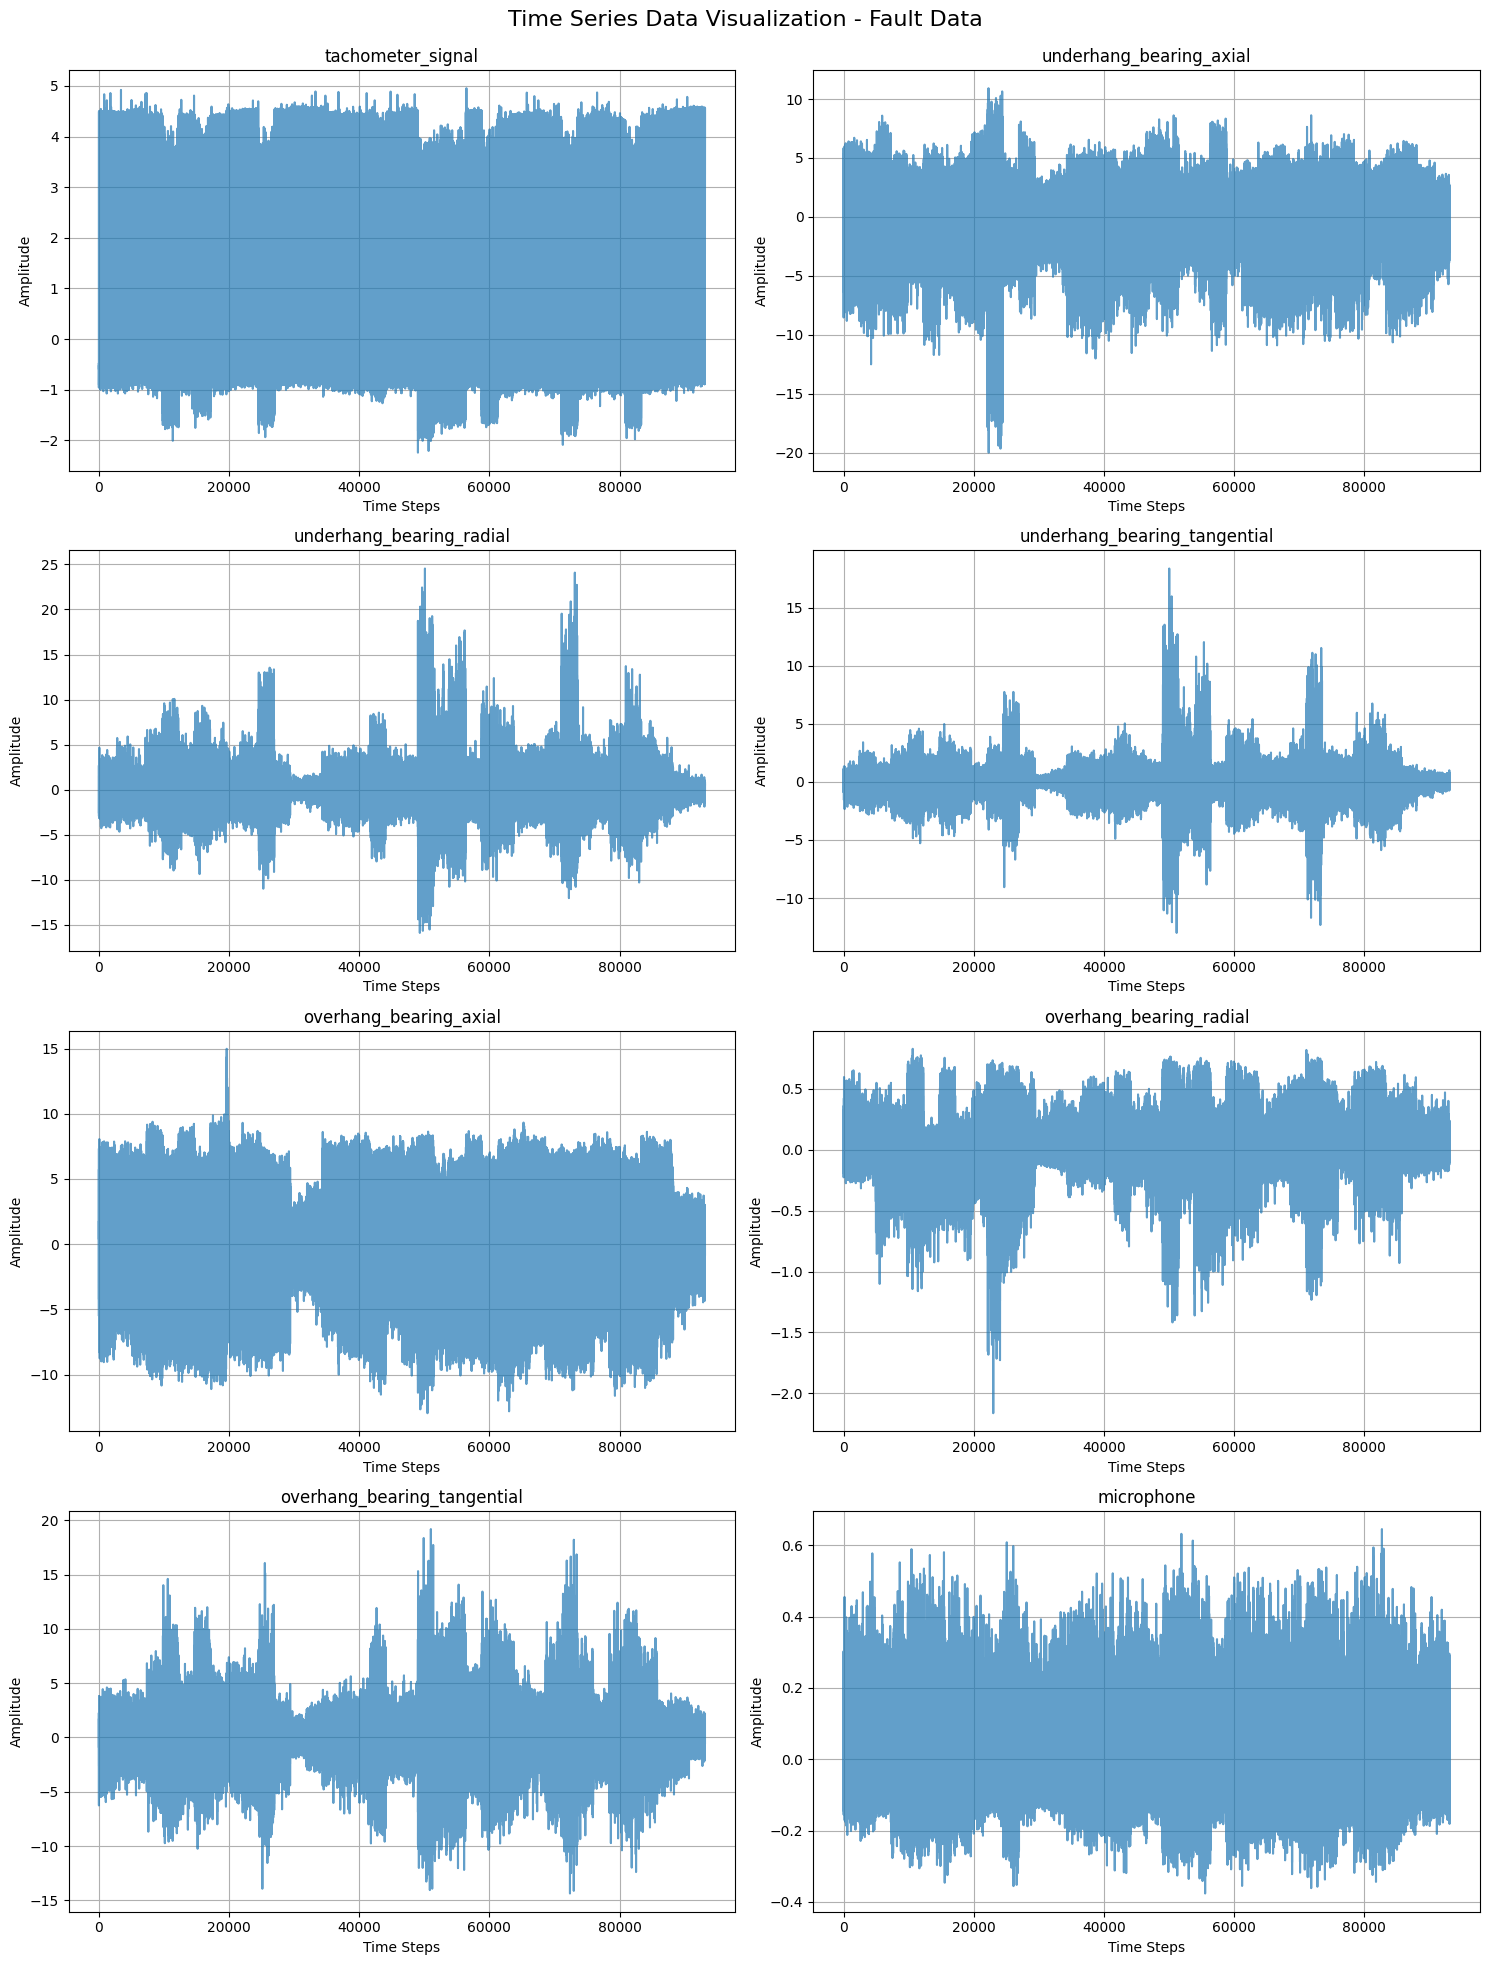

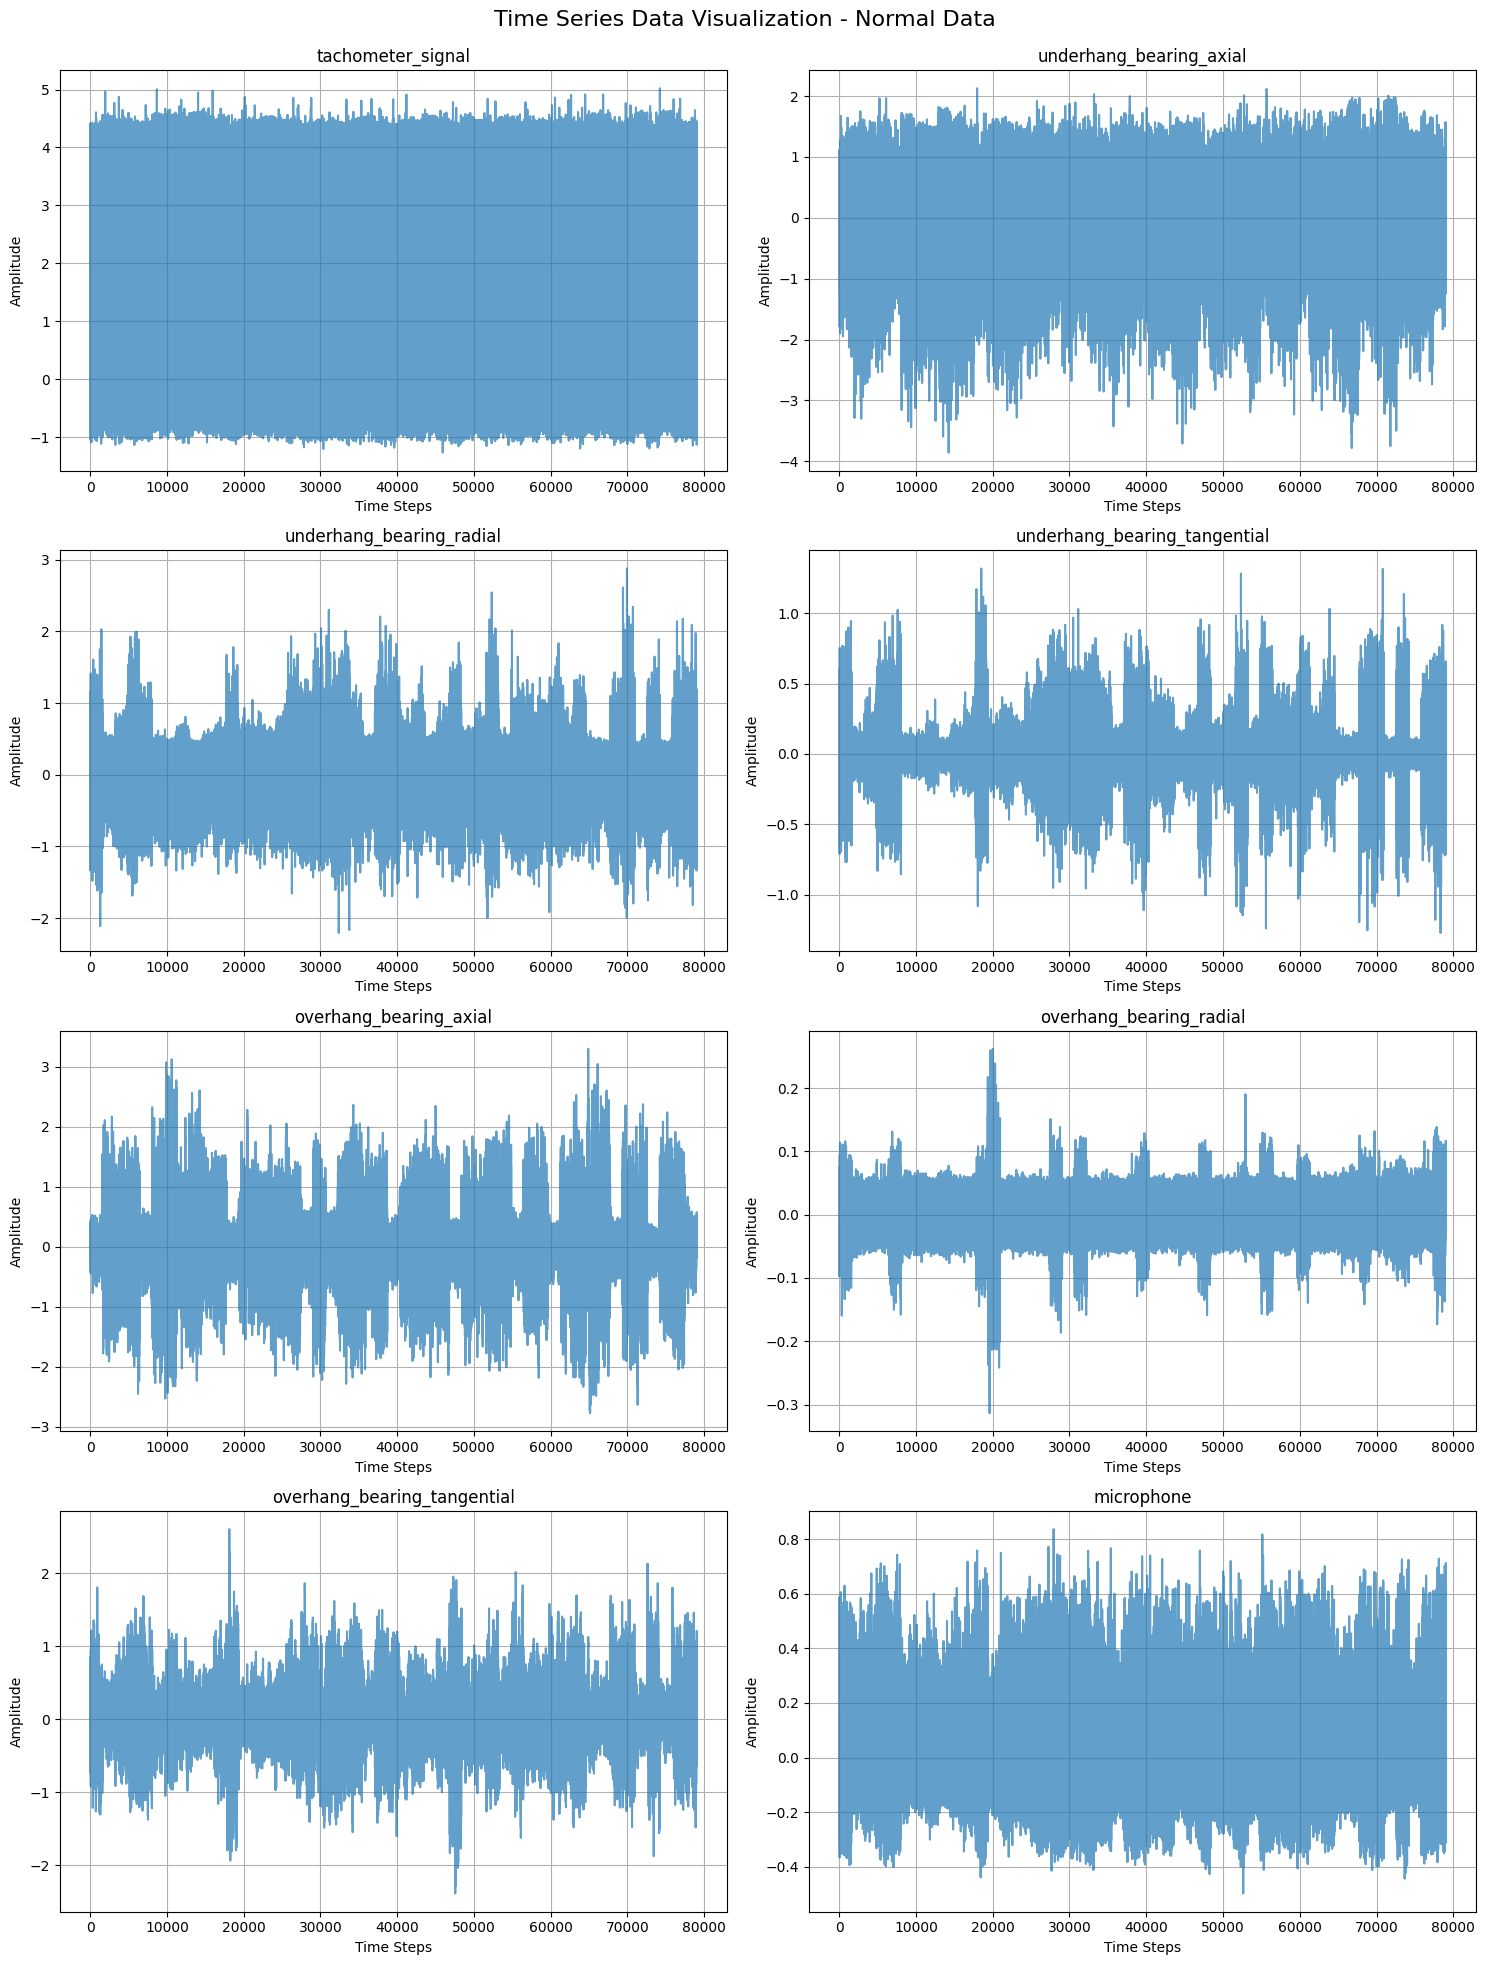

In [11]:
column_names = [
    'tachometer_signal',  # Column 1
    'underhang_bearing_axial', 'underhang_bearing_radial', 'underhang_bearing_tangential',  # Columns 2 to 4
    'overhang_bearing_axial', 'overhang_bearing_radial', 'overhang_bearing_tangential',  # Columns 5 to 7
    'microphone'  # Column 8
]

# Load CSV file into a DataFrame
df_fault = pd.read_csv('./data/combined/fault_underhang_35g_bearing_500Hz.csv') 
df_normal = pd.read_csv('./data/combined/normal_500Hz.csv')

dfs = {'Fault Data': df_fault, 'Normal Data': df_normal}  # Dictionary with descriptive names

for name, df in dfs.items():
    # df.columns = column_names
    # Create subplots for each column
    fig, axes = plt.subplots(4, 2, figsize=(15, 20))
    fig.suptitle(f'Time Series Data Visualization - {name}', fontsize=16)

    # Flatten axes for easier iteration
    axes = axes.flatten()

    # Plot each column
    for idx, column in enumerate(df.columns):
        axes[idx].plot(df[column], alpha=0.7)
        axes[idx].set_title(f'{column}')
        axes[idx].set_xlabel('Time Steps')
        axes[idx].set_ylabel('Amplitude')
        axes[idx].grid(True)

    # Remove empty subplot if number of columns is odd
    if len(df.columns) < len(axes):
        fig.delaxes(axes[-1])

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
